[2026-08-03 21:00:09] [info     ] 开始计算V3因子                       end_date='2024-12-31 23:59:59' start_date='2024-01-01 00:00:00'
[2026-08-03 21:00:10] [info     ] 开始构建训练集                        train_end='2023-12-31 23:59:59' train_start='2023-01-01 00:00:00'
[2026-08-03 21:00:10] [info     ] build_features开始               end='2023-12-31 23:59:59' need_label=True query_end='2024-01-07 23:59:59' query_start='2022-10-23 00:00:00' start='2023-01-01 00:00:00'
[2026-08-03 21:03:47] [info     ] 分钟行情聚合完成                       elapsed=216.82 rows=636420
[2026-08-03 21:03:48] [info     ] 日频及压力特征完成                      elapsed=1.42
[2026-08-03 21:03:48] [info     ] 财务数据查询完成                       elapsed=0.16 rows=18333
[2026-08-03 21:03:52] [info     ] build_features完成               dates=242 elapsed=221.69 instruments=1201 rows=241631
[2026-08-03 21:03:52] [info     ] 特征缺失率筛选完成                      original_features=37 removed_features=[] usable_features=37
[2026-08-03 21:03:52] [info     ] 训练

时段,IC
2024-01-15~2024-02-08,0.0168
2024-09-24~2024-10-08,0.0592

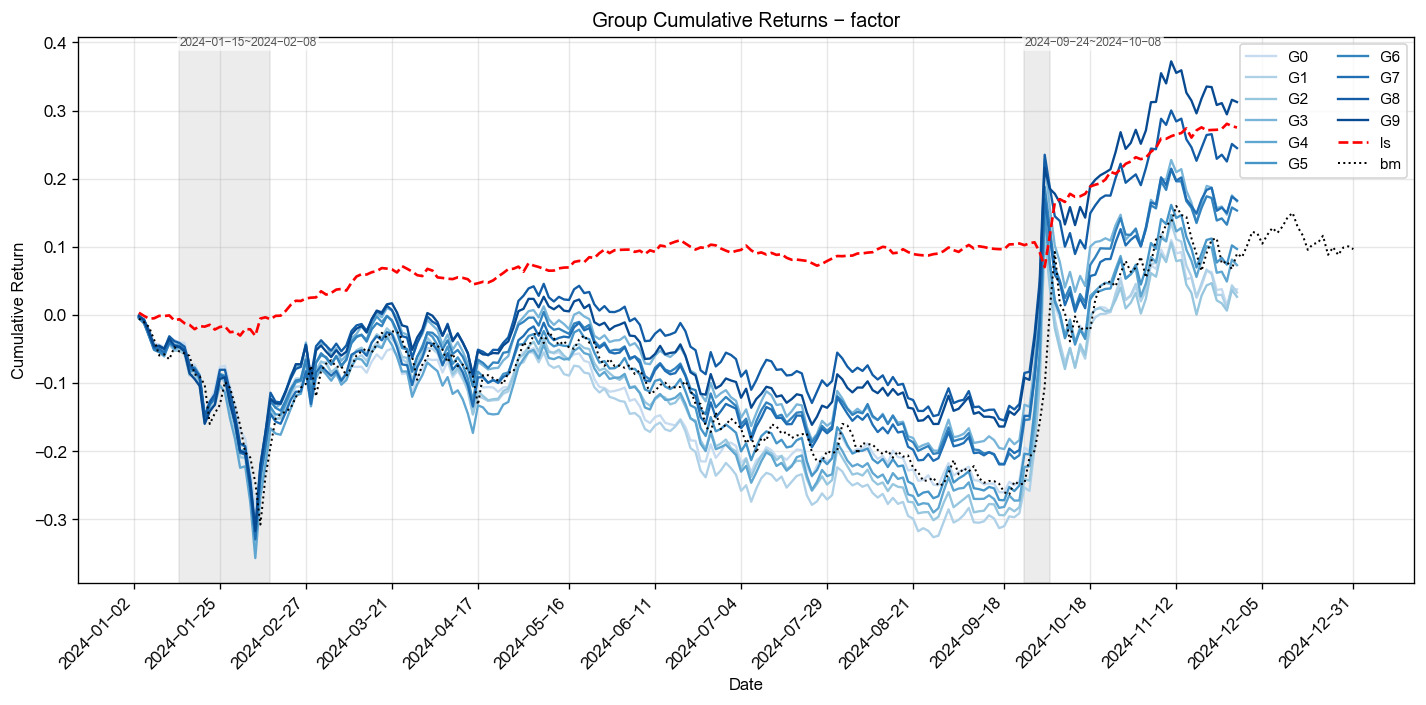
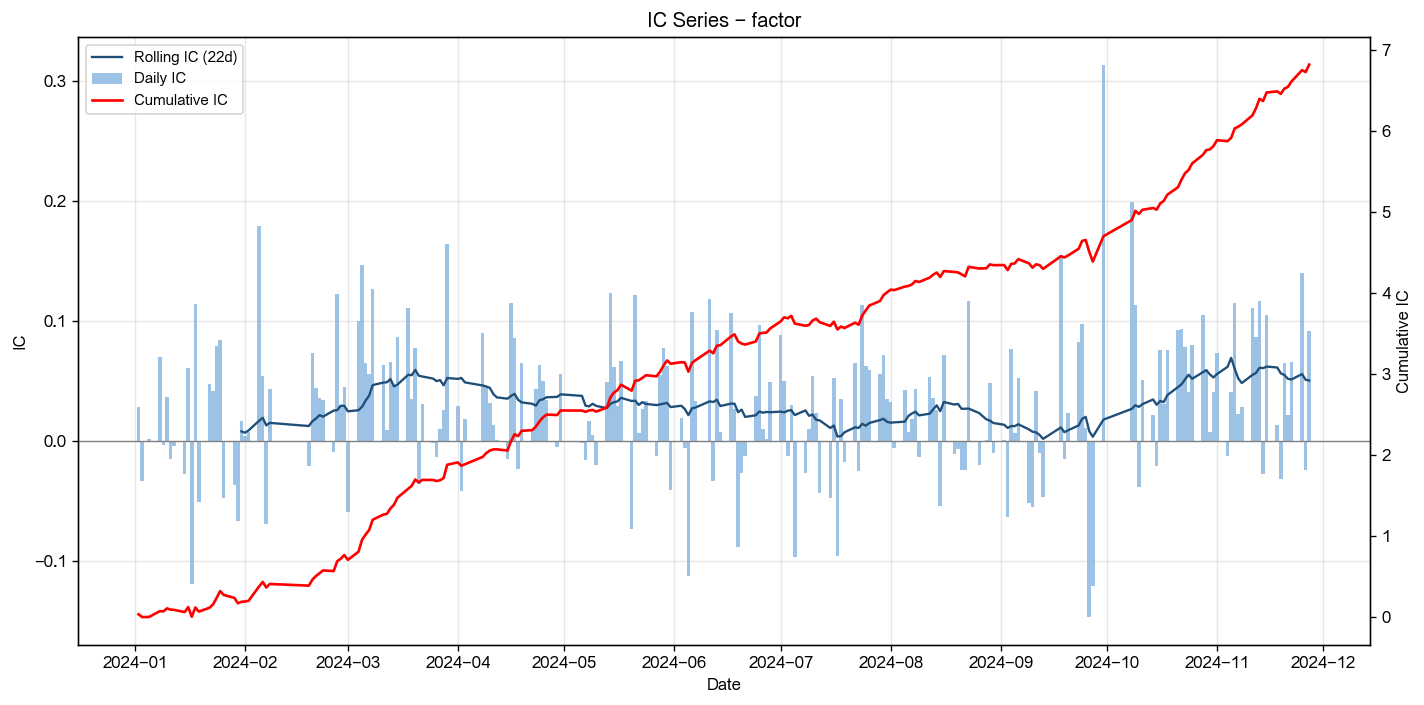
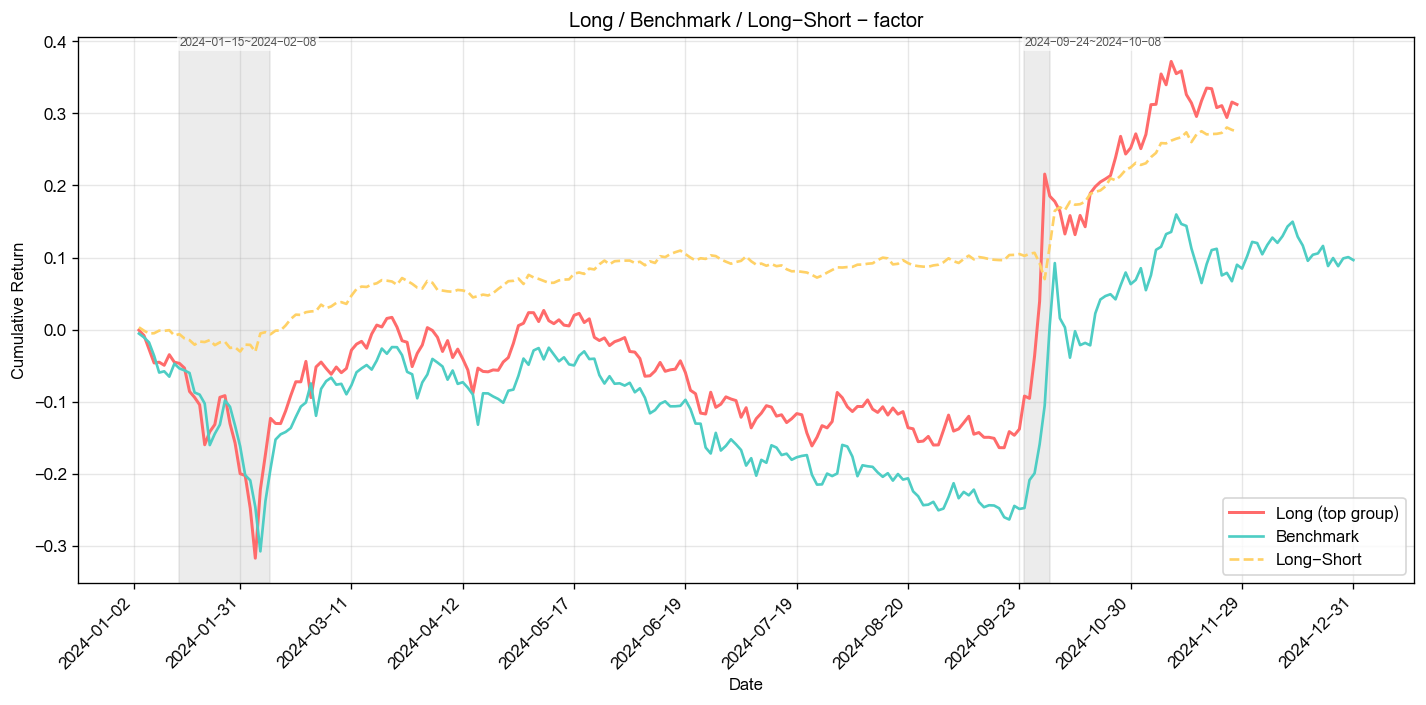
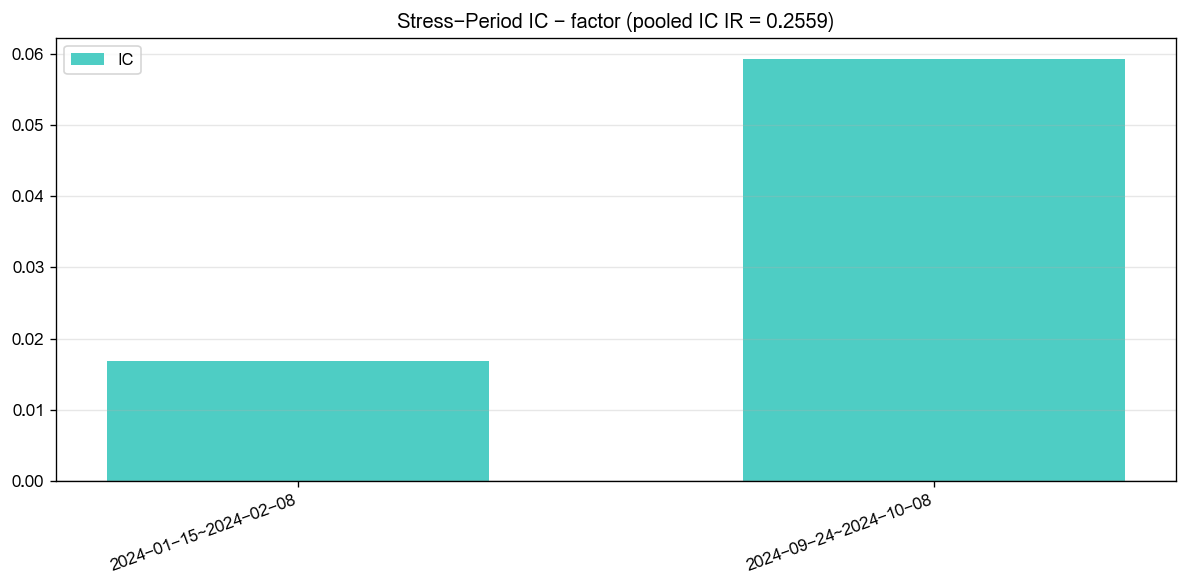
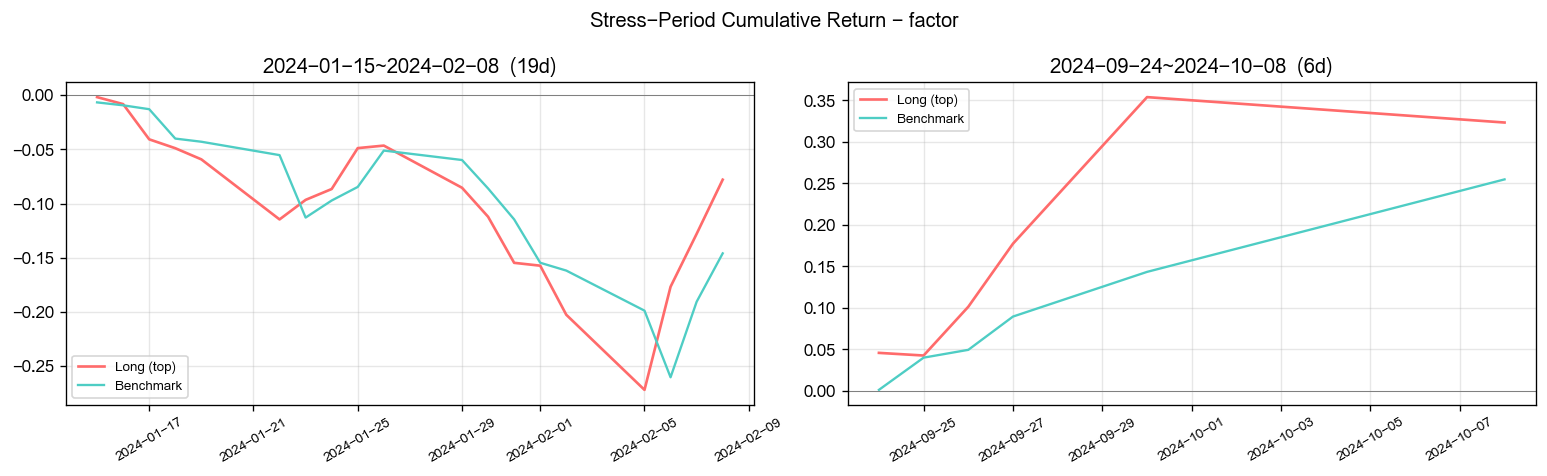

[2026-08-03 21:07:23] [info     ] ========== 因子池回归 ==========
[2026-08-03 21:07:28] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-08-03 21:07:30] [info     ] 获取收益率数据, 耗时: 7.0659 秒
[2026-08-03 21:07:30] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.7702 秒
[2026-08-03 21:07:30] [info     ] 统计 回归结果, 耗时: 0.0073 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,2.4102,0.0228,0.0095,1.0000
2,rsi_12,2.1366,0.0444,0.0208,1.0000
3,amount,1.7286,0.0181,0.0105,0.9000
4,netflow_amount_main,1.5756,0.0267,0.0169,1.0000
5,pb,1.5322,0.0101,0.0066,1.0000
6,gross_profit_rate_ttm,1.5038,0.0065,0.0044,1.0000
7,net_profit_rate_ttm,1.4826,0.0040,0.0027,0.8000
8,cci_14,1.4444,0.0343,0.0238,1.0000
9,bias_20,1.4113,0.0288,0.0204,0.9000
10,volatility_5,1.3275,0.0167,0.0126,1.0000

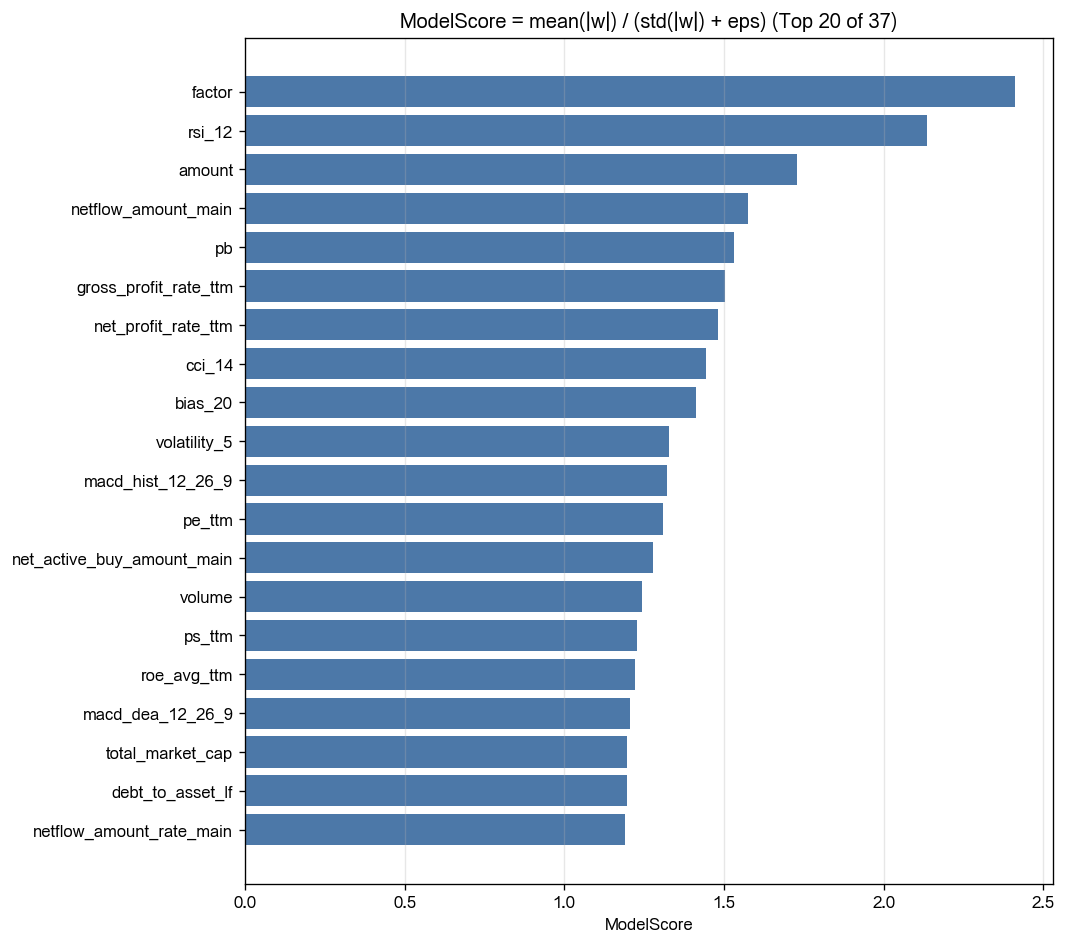
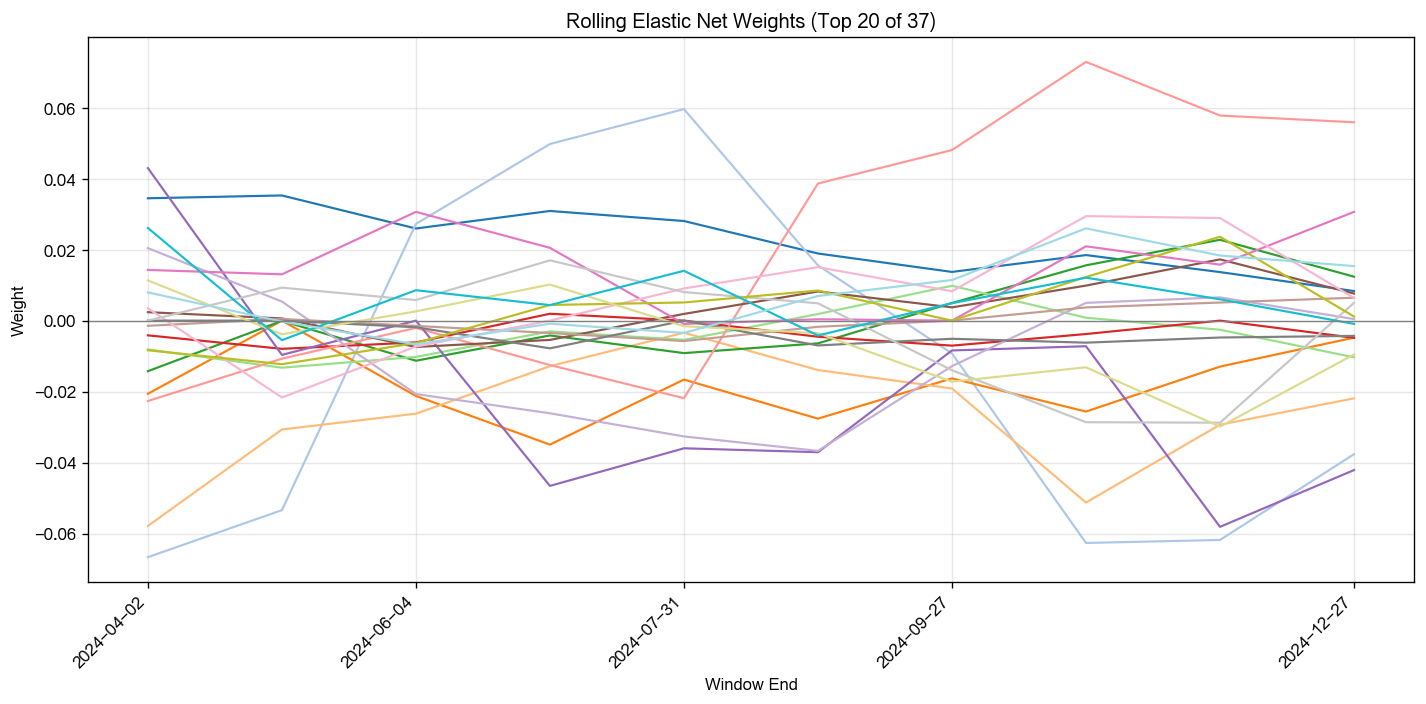
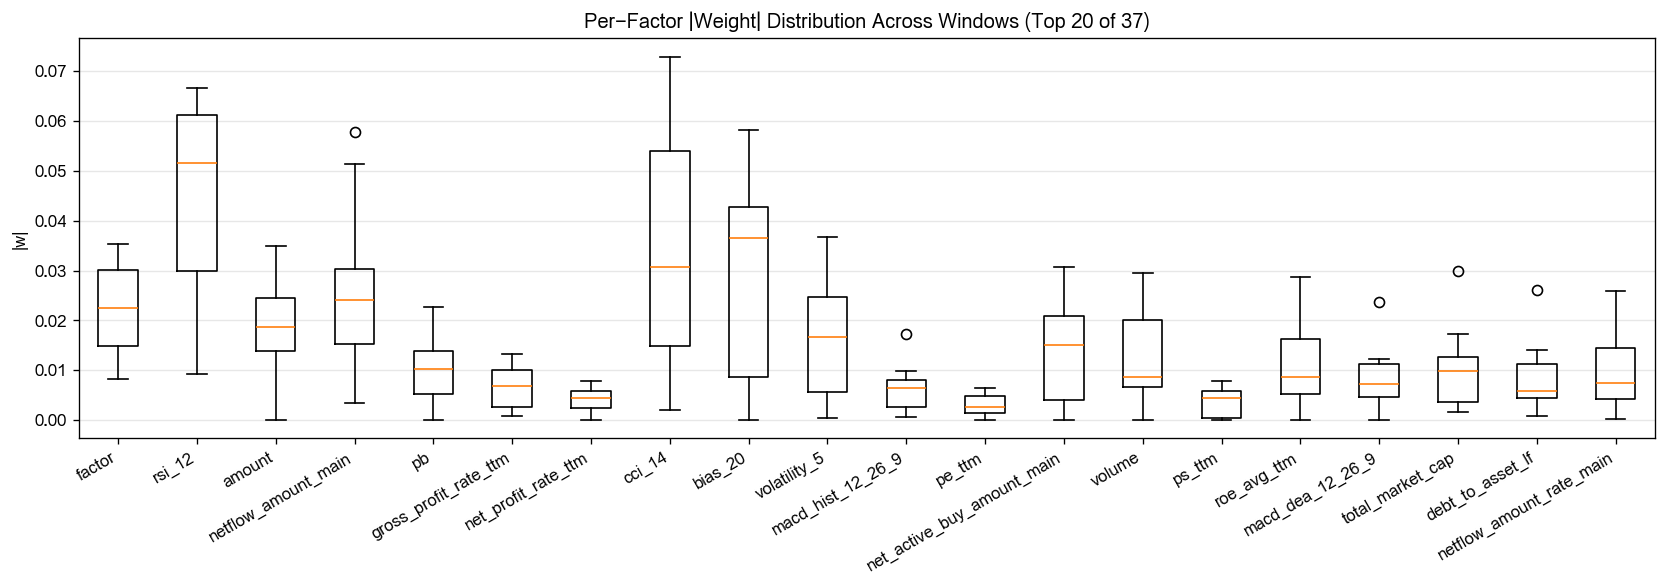
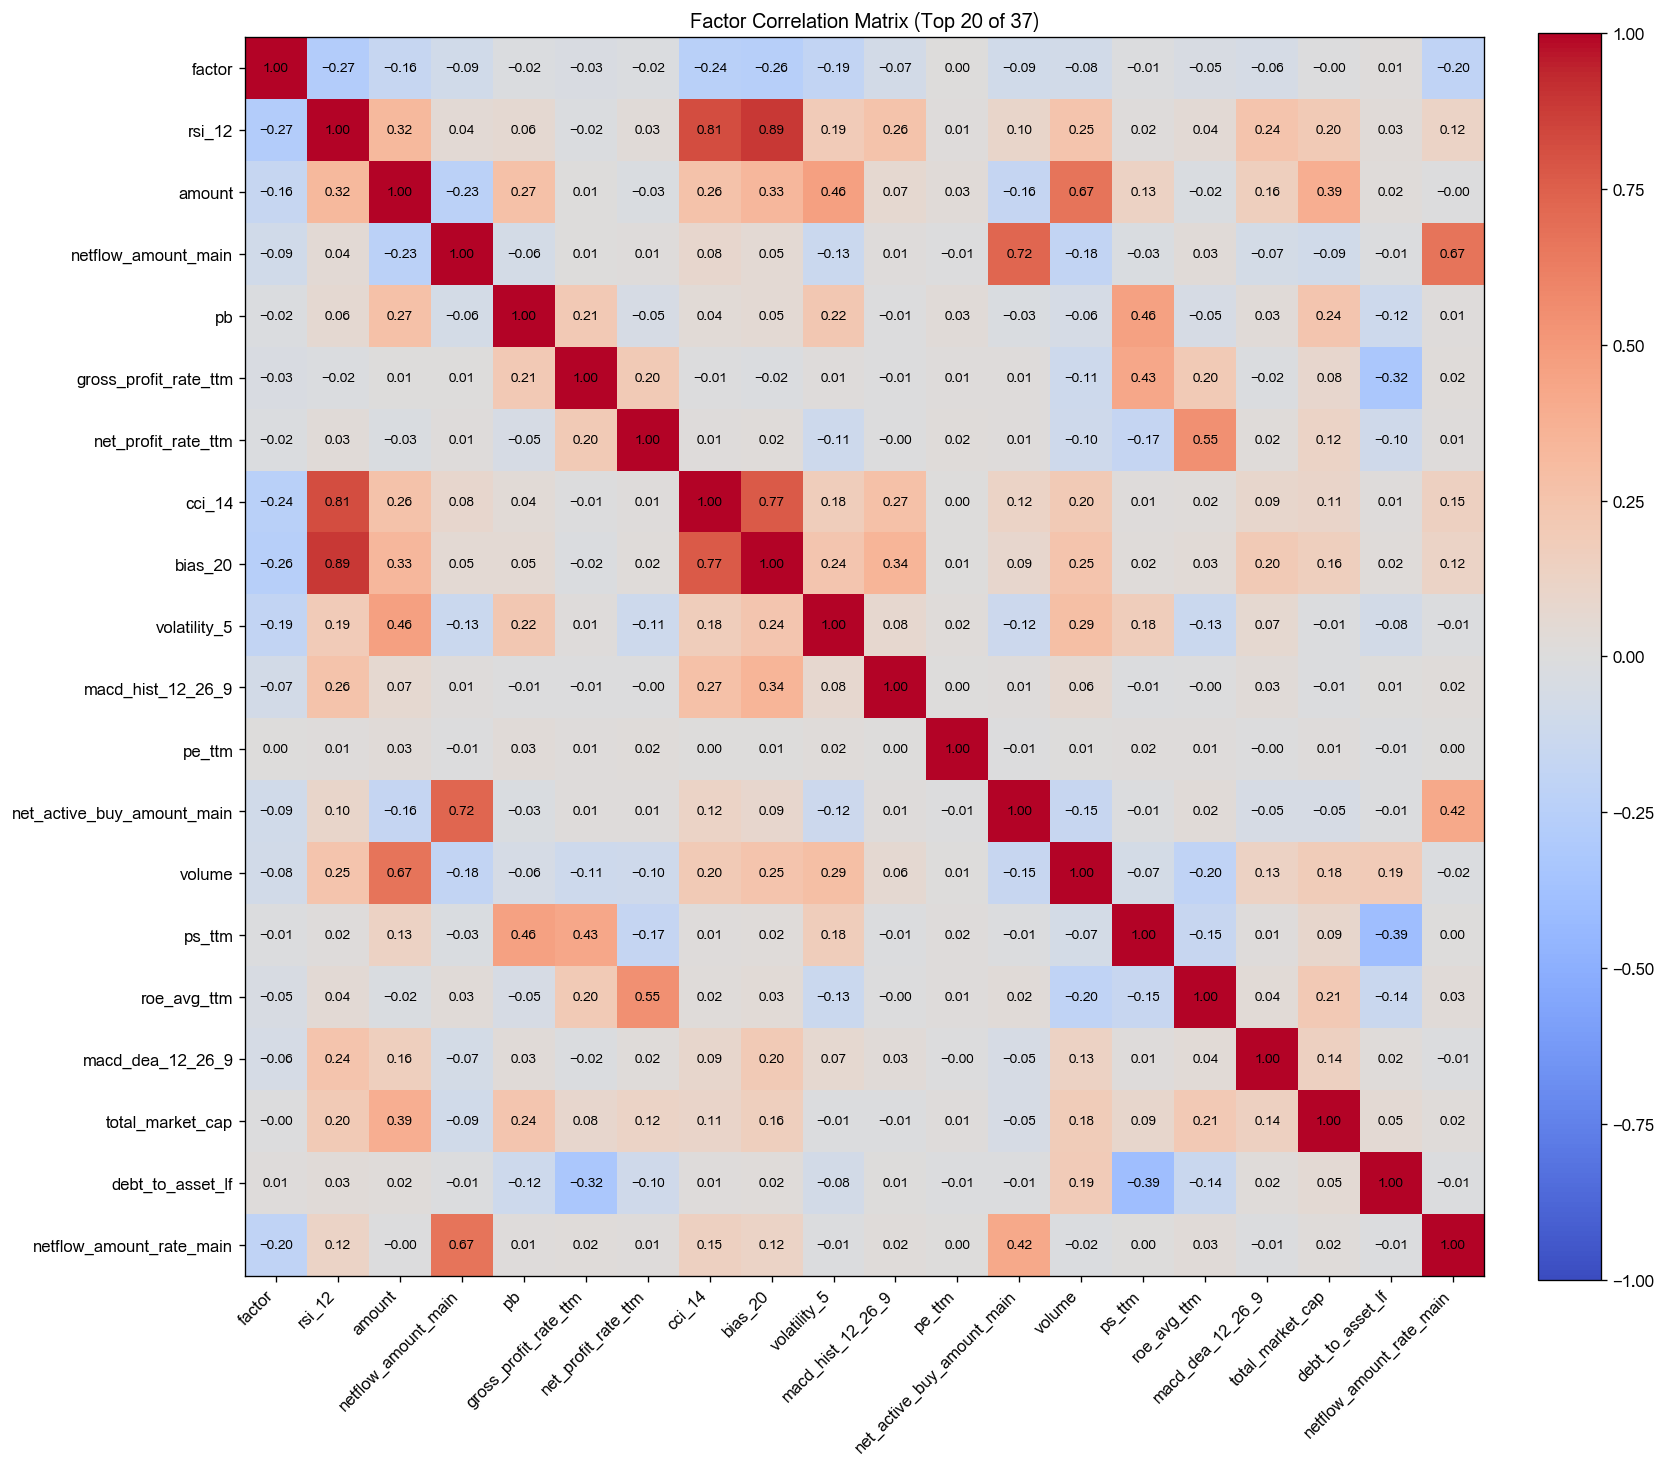

[2026-08-03 21:07:32] [warning  ] 返回的Outputs实例(size=34612419) 大于 64K, 将不会被缓存
[2026-08-03 21:07:32] [info     ] bigalpha_eval.v4 运行完成 [42.207s].
{'raw_factor':              date instrument    factor
0      2024-01-02  000006.SZ  0.007523
1      2024-01-02  000012.SZ  0.392678
2      2024-01-02  000016.SZ -0.148947
3      2024-01-02  000019.SZ -0.321464
4      2024-01-02  000025.SZ -0.069709
...           ...        ...       ...
241765 2024-12-31  688766.SH -0.330831
241766 2024-12-31  688776.SH -0.088589
241767 2024-12-31  688779.SH  0.433934
241768 2024-12-31  688789.SH -0.487988
241769 2024-12-31  688798.SH -0.331832

[241770 rows x 3 columns], 'process_factor':              date instrument    factor
0      2024-01-02  000006.SZ -0.040811
1      2024-01-02  000012.SZ  0.942250
2      2024-01-02  000016.SZ -0.756109
3      2024-01-02  000019.SZ -1.540330
4      2024-01-02  000025.SZ -0.960666
...           ...        ...       ...
241995 2024-12-31  688766.SH -0.922086
241996 2024-12-

In [1]:
def main(datasources, start_date, end_date):
    """
    V3：多维信息融合 XGBoost 因子

    核心思想：
        融合日内交易行为、市场状态、压力环境、财务质量以及非线性交互特征，
        利用 XGBoost 学习股票横截面未来收益预测关系，生成样本外因子。

    特征体系：
        1. 日内交易结构：
        - 尾盘收益
        - 尾盘成交量占比
        - 分钟级上涨比例
        - 实现波动率
        - 日内交易节奏

        2. 风险状态特征：
        - 短中期波动变化
        - 下行波动率
        - 最大回撤
        - 市场波动状态

        3. 财务质量特征：
        - 盈利能力
        - 资产质量
        - 财务稳定性

        4. 交互增强特征：
        - 动量与成交确认
        - 超跌与尾盘修复
        - 质量与低波动组合
        - 流动性与基本面结合

    训练逻辑：
        使用固定历史训练区间训练模型，不使用平台传入的测试区间数据，
        避免未来函数和数据泄漏。

    测试逻辑：
        使用平台传入的 start_date/end_date 构造样本外特征，
        通过训练完成的模型预测因子值。

    返回：
        pd.DataFrame，包含：
        ['date', 'instrument', 'factor']
    """
    import gc
    import time
    import numpy as np
    import pandas as pd
    import dai
    import xgboost as xgb
    import structlog

    logger = structlog.get_logger()

    # ============================================================
    # 1. 基本配置
    # ============================================================

    # 正式测试区间假设从 2024 年开始。
    # 如果正式测试区间更早，必须相应提前 TRAIN_END。
    TRAIN_START = '2023-01-01 00:00:00'
    TRAIN_END = '2023-12-31 23:59:59'

    # 最长滚动窗口为 20 个交易日。
    # 向前读取 70 个自然日，通常能够覆盖足够交易日。
    LOOKBACK_DAYS = 70

    # 训练集末尾需要向后读取几个自然日，构造下一交易日标签。
    LABEL_FORWARD_DAYS = 7

    # ============================================================
    # 2. 特征配置
    # ============================================================

    financial_raw_cols = [
        'operating_revenue',
        'net_profit_to_parent_shareholders',
        'total_assets',
        'total_equity_to_parent_shareholders',
    ]

    base_feature_cols = [
        'ret_1d',
        'ret_5d',
        'ret_20d',
        'intraday_ret',
        'overnight_ret',
        'high_low_range',
        'close_position',

        'volatility_5d',
        'volatility_20d',
        'volume_ratio_20d',
        'amount_ratio_20d',

        'last30m_ret',
        'last30m_volume_ratio',
        'up_minute_ratio',
        'realized_volatility',
        'am_pm_ret_diff',

        'volatility_change',
        'downside_volatility_20d',
        'max_drawdown_20d',

        'roe_proxy',
        'roa_proxy',
        'net_margin',
        'equity_asset_ratio',
        'asset_log',

        # V3 交互特征
        'momentum_volume',
        'oversold_reversal',
        'quality_stable',
        'return_confirm',
        'tail_strength',
        'vol_reversal',
        'financial_defense',
        'liquidity_quality',

        # V3 市场状态特征
        'excess_ret_1d',
        'excess_ret_5d',
        'excess_ret_20d',
        'market_volatility',
        'market_stress'
    ]

    # 模型最终输入每日截面排名特征。
    feature_cols = [
        f'{col}_rank'
        for col in base_feature_cols
    ]

    # ============================================================
    # 3. 工具函数
    # ============================================================

    def safe_divide(numerator, denominator):
        """
        安全除法：
        - 分母绝对值太小时转成 NaN；
        - 清除正负无穷。
        """
        denominator = denominator.where(
            denominator.abs() > 1e-12,
            np.nan
        )

        result = numerator / denominator

        return result.replace(
            [np.inf, -np.inf],
            np.nan
        )

    def query_stock_pool(sd, ed):
        """
        查询给定日期范围内的中证1000历史成分股。
        """
        pool = dai.query(
            """
            SELECT date, instrument
            FROM bigalpha_2026_instruments
            """,
            filters={
                'date': [sd, ed]
            }
        ).df()

        if pool.empty:
            return pd.DataFrame(
                columns=['date', 'instrument']
            )

        pool['date'] = pd.to_datetime(pool['date'])
        pool['instrument'] = pool['instrument'].astype(str)

        pool = (
            pool.drop_duplicates(
                subset=['date', 'instrument']
            )
            .sort_values(['date', 'instrument'])
            .reset_index(drop=True)
        )

        return pool

    # ============================================================
    # 4. 构建特征
    # ============================================================

    def build_features(
        financial_table,
        bar1m_table,
        sd,
        ed,
        need_label
    ):
        """
        构造指定时间区间的特征。

        need_label=True：
            构造训练标签。

        need_label=False：
            只生成预测特征。
        """
        total_start = time.time()

        sd_ts = pd.to_datetime(sd)
        ed_ts = pd.to_datetime(ed)

        query_start = (
            sd_ts -
            pd.Timedelta(days=LOOKBACK_DAYS)
        )

        if need_label:
            query_end = (
                ed_ts +
                pd.Timedelta(days=LABEL_FORWARD_DAYS)
            )
        else:
            query_end = ed_ts

        logger.info(
            "build_features开始",
            start=str(sd_ts),
            end=str(ed_ts),
            query_start=str(query_start),
            query_end=str(query_end),
            need_label=need_label
        )

        # ========================================================
        # 4.1 分钟行情聚合
        # ========================================================

        query_price_start = time.time()

        # minute_base：
        #   计算每只股票每天的分钟顺序、分钟收益和倒序位置。
        #
        # daily_bar：
        #   将分钟行情聚合为日线，并生成 V2 日内结构特征。
        price_sql = f"""
        WITH minute_base AS (
            SELECT
                date,
                date_trunc('day', date)::DATE AS trading_day,
                instrument,
                open,
                high,
                low,
                close,
                volume,
                amount,

                LAG(close) OVER (
                    PARTITION BY
                        instrument,
                        date_trunc('day', date)
                    ORDER BY date
                ) AS previous_minute_close,

                ROW_NUMBER() OVER (
                    PARTITION BY
                        instrument,
                        date_trunc('day', date)
                    ORDER BY date DESC
                ) AS reverse_minute_number

            FROM {bar1m_table}
        ),

        daily_bar AS (
            SELECT
                trading_day,
                instrument,

                ARG_MIN(open, date) AS open,
                MAX(high) AS high,
                MIN(low) AS low,
                ARG_MAX(close, date) AS close,

                SUM(volume) AS volume,
                SUM(amount) AS amount,

                -- 收盘前第30分钟的收盘价
                MAX(
                    CASE
                        WHEN reverse_minute_number = 30
                        THEN close
                        ELSE NULL
                    END
                ) AS last30m_start_close,

                -- 最后30分钟成交量
                SUM(
                    CASE
                        WHEN reverse_minute_number <= 30
                        THEN volume
                        ELSE 0
                    END
                ) AS last30m_volume,

                -- 分钟上涨比例
                AVG(
                    CASE
                        WHEN previous_minute_close IS NULL
                        THEN NULL
                        WHEN close > previous_minute_close
                        THEN 1.0
                        ELSE 0.0
                    END
                ) AS up_minute_ratio,

                -- 分钟收益平方和
                SUM(
                    CASE
                        WHEN previous_minute_close IS NULL
                             OR previous_minute_close = 0
                        THEN 0.0
                        ELSE POWER(
                            close / previous_minute_close - 1.0,
                            2
                        )
                    END
                ) AS realized_variance,

                -- 上午最后一个分钟收盘价
                ARG_MAX(
                    CASE
                        WHEN EXTRACT(HOUR FROM date) < 12
                        THEN close
                        ELSE NULL
                    END,
                    date
                ) AS morning_close,

                -- 下午第一分钟开盘价
                ARG_MIN(
                    CASE
                        WHEN EXTRACT(HOUR FROM date) >= 13
                        THEN open
                        ELSE NULL
                    END,
                    date
                ) AS afternoon_open

            FROM minute_base
            GROUP BY
                trading_day,
                instrument
        )

        SELECT
            trading_day,
            instrument,
            open,
            high,
            low,
            close,
            volume,
            amount,
            last30m_start_close,
            last30m_volume,
            up_minute_ratio,
            realized_variance,
            morning_close,
            afternoon_open

        FROM daily_bar

        ORDER BY
            trading_day,
            instrument
        """

        price = dai.query(
            price_sql,
            filters={
                'date': [
                    query_start,
                    query_end
                ]
            }
        ).df()

        price = price.rename(
            columns={
                'trading_day': 'date'
            }
        )

        if price.empty:
            logger.warning("分钟行情查询结果为空")

            return pd.DataFrame(
                columns=[
                    'date',
                    'instrument',
                    *feature_cols,
                    'label',
                    'next_ret'
                ]
            )

        price['date'] = pd.to_datetime(price['date'])
        price['instrument'] = price['instrument'].astype(str)

        numeric_price_cols = [
            'open',
            'high',
            'low',
            'close',
            'volume',
            'amount',
            'last30m_start_close',
            'last30m_volume',
            'up_minute_ratio',
            'realized_variance',
            'morning_close',
            'afternoon_open',
        ]

        for col in numeric_price_cols:
            price[col] = pd.to_numeric(
                price[col],
                errors='coerce'
            )

            price[col] = price[col].replace(
                [np.inf, -np.inf],
                np.nan
            )

        price = (
            price.sort_values(
                ['instrument', 'date']
            )
            .drop_duplicates(
                subset=['date', 'instrument'],
                keep='last'
            )
            .reset_index(drop=True)
        )

        logger.info(
            "分钟行情聚合完成",
            rows=len(price),
            elapsed=round(
                time.time() - query_price_start,
                2
            )
        )

        # ========================================================
        # 4.2 构造下一交易日收益
        # ========================================================

        close_group = price.groupby(
            'instrument',
            sort=False
        )['close']

        next_close = close_group.shift(-1)

        price['next_ret'] = (
            safe_divide(
                next_close,
                price['close']
            ) - 1
        )

        # ========================================================
        # 4.3 日频量价特征
        # ========================================================

        daily_feature_start = time.time()

        grouped = price.groupby(
            'instrument',
            sort=False,
            group_keys=False
        )

        previous_close = grouped['close'].shift(1)
        close_5d_ago = grouped['close'].shift(5)
        close_20d_ago = grouped['close'].shift(20)

        price['ret_1d'] = (
            safe_divide(
                price['close'],
                previous_close
            ) - 1
        )

        price['ret_5d'] = (
            safe_divide(
                price['close'],
                close_5d_ago
            ) - 1
        )

        price['ret_20d'] = (
            safe_divide(
                price['close'],
                close_20d_ago
            ) - 1
        )

        

        price['intraday_ret'] = (
            safe_divide(
                price['close'],
                price['open']
            ) - 1
        )

        price['overnight_ret'] = (
            safe_divide(
                price['open'],
                previous_close
            ) - 1
        )

        price['high_low_range'] = (
            safe_divide(
                price['high'],
                price['low']
            ) - 1
        )

        price['close_position'] = safe_divide(
            price['close'] - price['low'],
            price['high'] - price['low']
        )

        # ========================================================
        # 4.4 V2 分钟级结构特征
        # ========================================================

        price['last30m_ret'] = (
            safe_divide(
                price['close'],
                price['last30m_start_close']
            ) - 1
        )

        price['last30m_volume_ratio'] = safe_divide(
            price['last30m_volume'],
            price['volume']
        )

        price['realized_volatility'] = np.sqrt(
            price['realized_variance'].clip(lower=0)
        )

        morning_ret = (
            safe_divide(
                price['morning_close'],
                price['open']
            ) - 1
        )

        afternoon_ret = (
            safe_divide(
                price['close'],
                price['afternoon_open']
            ) - 1
        )

        # 上午强、下午弱时该值为正；
        # 上午弱、下午强时该值为负。
        price['am_pm_ret_diff'] = (
            morning_ret - afternoon_ret
        )

        # ========================================================
        # 4.5 滚动波动与成交特征
        # ========================================================

        ret_group = price.groupby(
            'instrument',
            sort=False
        )['ret_1d']

        price['volatility_5d'] = (
            ret_group
            .rolling(
                window=5,
                min_periods=3
            )
            .std()
            .reset_index(
                level=0,
                drop=True
            )
        )

        price['volatility_20d'] = (
            ret_group
            .rolling(
                window=20,
                min_periods=10
            )
            .std()
            .reset_index(
                level=0,
                drop=True
            )
        )

        volume_mean_20d = (
            price.groupby(
                'instrument',
                sort=False
            )['volume']
            .rolling(
                window=20,
                min_periods=5
            )
            .mean()
            .reset_index(
                level=0,
                drop=True
            )
        )

        amount_mean_20d = (
            price.groupby(
                'instrument',
                sort=False
            )['amount']
            .rolling(
                window=20,
                min_periods=5
            )
            .mean()
            .reset_index(
                level=0,
                drop=True
            )
        )

        price['volume_ratio_20d'] = safe_divide(
            price['volume'],
            volume_mean_20d
        )

        price['amount_ratio_20d'] = safe_divide(
            price['amount'],
            amount_mean_20d
        )

        # ========================================================
        # 4.6 V2 压力行情特征
        # ========================================================

        # 短期波动相对于中期波动的放大程度。
        price['volatility_change'] = safe_divide(
            price['volatility_5d'],
            price['volatility_20d']
        )

        # 下跌日收益。上涨日设置为0。
        price['downside_ret'] = price['ret_1d'].where(
            price['ret_1d'] < 0,
            0.0
        )

        price['downside_volatility_20d'] = (
            price.groupby(
                'instrument',
                sort=False
            )['downside_ret']
            .rolling(
                window=20,
                min_periods=10
            )
            .std()
            .reset_index(
                level=0,
                drop=True
            )
        )

        # 先计算当前价格相对过去20日最高价的回撤。
        rolling_high_20d = (
            price.groupby(
                'instrument',
                sort=False
            )['close']
            .rolling(
                window=20,
                min_periods=10
            )
            .max()
            .reset_index(
                level=0,
                drop=True
            )
        )

        price['current_drawdown'] = (
            safe_divide(
                price['close'],
                rolling_high_20d
            ) - 1
        )

        # 当前窗口中最严重的回撤。
        price['max_drawdown_20d'] = (
            price.groupby(
                'instrument',
                sort=False
            )['current_drawdown']
            .rolling(
                window=20,
                min_periods=10
            )
            .min()
            .reset_index(
                level=0,
                drop=True
            )
        )

        market_daily = price.groupby('date')['ret_1d'].mean()

        market_vol = price.groupby('date')['ret_1d'].std()

        price = price.merge(
            market_daily.rename('market_ret_1d'),
            on='date',
            how='left'
        )

        price = price.merge(
            market_vol.rename('market_volatility'),
            on='date',
            how='left'
        )

        price['market_stress'] = price['market_volatility']

        price['excess_ret_1d'] = price['ret_1d'] - price['market_ret_1d']

        price['excess_ret_5d'] = price['ret_5d'] - price.groupby('date')['ret_5d'].transform('mean')

        price['excess_ret_20d'] = price['ret_20d'] - price.groupby('date')['ret_20d'].transform('mean')        

        logger.info(
            "日频及压力特征完成",
            elapsed=round(
                time.time() - daily_feature_start,
                2
            )
        )

        # ========================================================
        # 4.7 查询 PIT 财务数据
        # ========================================================

        financial_start = time.time()

        financial_query_start = (
            query_start -
            pd.Timedelta(days=400)
        )

        fin_select = ', '.join(financial_raw_cols)

        financial_sql = f"""
        SELECT
            date,
            instrument,
            {fin_select}
        FROM {financial_table}
        WHERE category = 'lf'
          AND shift = 0
        """

        fin = dai.query(
            financial_sql,
            filters={
                'date': [
                    financial_query_start,
                    query_end
                ]
            }
        ).df()

        if not fin.empty:
            fin['date'] = pd.to_datetime(fin['date'])
            fin['instrument'] = fin['instrument'].astype(str)

            for col in financial_raw_cols:
                fin[col] = pd.to_numeric(
                    fin[col],
                    errors='coerce'
                )

                fin[col] = fin[col].replace(
                    [np.inf, -np.inf],
                    np.nan
                )

            fin = (
                fin.sort_values(
                    ['date', 'instrument']
                )
                .drop_duplicates(
                    subset=['date', 'instrument'],
                    keep='last'
                )
                .reset_index(drop=True)
            )

        logger.info(
            "财务数据查询完成",
            rows=len(fin),
            elapsed=round(
                time.time() - financial_start,
                2
            )
        )

        # ========================================================
        # 4.8 使用 merge_asof 进行 PIT 合并
        # ========================================================

        price = (
            price.sort_values(
                ['date', 'instrument']
            )
            .reset_index(drop=True)
        )

        if fin.empty:
            df = price.copy()

            for col in financial_raw_cols:
                df[col] = np.nan

        else:
            # 每个交易日只匹配当日或此前最近一次财务公告。
            df = pd.merge_asof(
                price,
                fin,
                on='date',
                by='instrument',
                direction='backward',
                allow_exact_matches=True
            )

        # ========================================================
        # 4.9 财务质量特征
        # ========================================================

        df['roe_proxy'] = safe_divide(
            df['net_profit_to_parent_shareholders'],
            df[
                'total_equity_to_parent_shareholders'
            ].abs()
        )

        df['roa_proxy'] = safe_divide(
            df['net_profit_to_parent_shareholders'],
            df['total_assets'].abs()
        )

        df['net_margin'] = safe_divide(
            df['net_profit_to_parent_shareholders'],
            df['operating_revenue'].abs()
        )

        df['equity_asset_ratio'] = safe_divide(
            df[
                'total_equity_to_parent_shareholders'
            ],
            df['total_assets'].abs()
        )

        df['asset_log'] = np.log1p(
            df['total_assets'].clip(lower=0)
        )

        df['momentum_volume'] = df['ret_20d'] * df['volume_ratio_20d']

        df['oversold_reversal'] = -df['ret_5d'] * df['last30m_ret']

        df['quality_stable'] = df['roe_proxy'] / (df['volatility_20d'] + 1e-8)

        df['return_confirm'] = df['ret_5d'] * df['amount_ratio_20d']

        df['tail_strength'] = df['last30m_ret'] * df['last30m_volume_ratio']

        df['vol_reversal'] = -df['ret_5d'] * df['volatility_change']

        df['financial_defense'] = df['roa_proxy'] - df['volatility_20d']

        df['liquidity_quality'] = df['roe_proxy'] * df['amount_ratio_20d']

        # ========================================================
        # 4.10 宽松异常值裁剪
        # ========================================================

        ratio_clip_cols = [
            'roe_proxy',
            'roa_proxy',
            'net_margin',
            'equity_asset_ratio',
        ]

        for col in ratio_clip_cols:
            df[col] = df[col].clip(
                lower=-10,
                upper=10
            )

        positive_clip_cols = [
            'volume_ratio_20d',
            'amount_ratio_20d',
            'volatility_change',
        ]

        for col in positive_clip_cols:
            df[col] = df[col].clip(
                lower=0,
                upper=20
            )

        df['last30m_volume_ratio'] = (
            df['last30m_volume_ratio']
            .clip(lower=0, upper=1)
        )

        df['up_minute_ratio'] = (
            df['up_minute_ratio']
            .clip(lower=0, upper=1)
        )

        # ========================================================
        # 4.11 对齐中证1000历史股票池
        # ========================================================

        pool = query_stock_pool(
            query_start,
            query_end
        )

        df = pd.merge(
            df,
            pool,
            how='inner',
            on=['date', 'instrument']
        )

        # ========================================================
        # 4.12 清理数值类型
        # ========================================================

        for col in base_feature_cols:
            df[col] = pd.to_numeric(
                df[col],
                errors='coerce'
            )

            df[col] = df[col].replace(
                [np.inf, -np.inf],
                np.nan
            )

        # ========================================================
        # 4.13 每日截面排名特征
        # ========================================================

        for col in base_feature_cols:
            rank_col = f'{col}_rank'

            df[rank_col] = (
                df.groupby(
                    'date',
                    sort=False
                )[col]
                .rank(
                    method='average',
                    pct=True
                )
            )

            # 从 [0,1] 居中到 [-0.5,0.5]。
            df[rank_col] = (
                df[rank_col] - 0.5
            )

        # ========================================================
        # 4.14 训练标签
        # ========================================================

        if need_label:
            # 对下一交易日收益做每日截面排名。
            df['label'] = (
                df.groupby(
                    'date',
                    sort=False
                )['next_ret']
                .rank(
                    method='average',
                    pct=True
                )
            )

            df['label'] = df['label'] - 0.5

        else:
            df['label'] = np.nan

        # ========================================================
        # 4.15 截取目标日期范围
        # ========================================================

        df = df[
            (df['date'] >= sd_ts) &
            (df['date'] <= ed_ts)
        ].copy()

        df = (
            df.sort_values(
                ['date', 'instrument']
            )
            .drop_duplicates(
                subset=['date', 'instrument'],
                keep='last'
            )
            .reset_index(drop=True)
        )

        logger.info(
            "build_features完成",
            rows=len(df),
            dates=int(df['date'].nunique()),
            instruments=int(
                df['instrument'].nunique()
            ),
            elapsed=round(
                time.time() - total_start,
                2
            )
        )

        return df

    # ============================================================
    # 5. 构建训练集
    # ============================================================

    logger.info(
        "开始构建训练集",
        train_start=TRAIN_START,
        train_end=TRAIN_END
    )

    train_df = build_features(
        financial_table='bigalpha_2026_financial',
        bar1m_table='bigalpha_2026_stock_bar1m',
        sd=TRAIN_START,
        ed=TRAIN_END,
        need_label=True
    )

    train_df['label'] = pd.to_numeric(
        train_df['label'],
        errors='coerce'
    )

    train_df['label'] = train_df['label'].replace(
        [np.inf, -np.inf],
        np.nan
    )

    train_df = train_df.dropna(
        subset=['label']
    )

    train_df = train_df.dropna(
        subset=feature_cols,
        how='all'
    )

    if train_df.empty:
        raise ValueError(
            "训练集为空，请检查训练日期和数据源。"
        )

    # ============================================================
    # 6. 删除高缺失率特征
    # ============================================================

    missing_rate = (
        train_df[feature_cols]
        .isna()
        .mean()
    )

    usable_feature_cols = [
        col
        for col in feature_cols
        if missing_rate[col] < 0.80
    ]

    removed_feature_cols = [
        col
        for col in feature_cols
        if col not in usable_feature_cols
    ]

    if not usable_feature_cols:
        raise ValueError(
            "全部特征缺失率过高，无法训练模型。"
        )

    logger.info(
        "特征缺失率筛选完成",
        original_features=len(feature_cols),
        usable_features=len(usable_feature_cols),
        removed_features=removed_feature_cols
    )

    # 只保留模型真正需要的列，减少内存压力。
    model_train_df = train_df[
        [
            'date',
            'instrument',
            'label',
            *usable_feature_cols
        ]
    ].copy()

    del train_df
    gc.collect()

    X_train = (
        model_train_df[usable_feature_cols]
        .astype(np.float32)
    )

    y_train = (
        model_train_df['label']
        .astype(np.float32)
    )

    logger.info(
        "训练数据准备完成",
        samples=len(X_train),
        features=X_train.shape[1],
        missing_ratio=round(
            float(X_train.isna().mean().mean()),
            6
        ),
        memory_mb=round(
            X_train.memory_usage(
                deep=True
            ).sum() / 1024 / 1024,
            2
        )
    )

    # ============================================================
    # 7. 训练 XGBoost
    # ============================================================

    fit_start = time.time()

    model = xgb.XGBRegressor(
        objective='reg:squarederror',

        # 先采用偏轻量配置，控制运行时间。
        n_estimators=50,
        max_depth=3,
        learning_rate=0.05,

        # 正则化和采样。
        min_child_weight=50,
        subsample=0.75,
        colsample_bytree=0.75,
        reg_alpha=0.1,
        reg_lambda=5.0,

        # 直方图算法。
        tree_method='hist',
        max_bin=128,

        # 平台环境下避免无限线程竞争。
        n_jobs=4,

        random_state=42,
        verbosity=1
    )

    logger.info(
        "开始训练模型",
        samples=len(X_train),
        features=len(usable_feature_cols)
    )

    model.fit(
        X_train,
        y_train
    )

    logger.info(
        "模型训练完成",
        elapsed=round(
            time.time() - fit_start,
            2
        )
    )

    importance = (
        pd.Series(
            model.feature_importances_,
            index=usable_feature_cols
        )
        .sort_values(ascending=False)
    )

    logger.info(
        "特征重要性前15名",
        importance=(
            importance
            .head(15)
            .round(6)
            .to_dict()
        )
    )

    del X_train
    del y_train
    del model_train_df
    gc.collect()

    # ============================================================
    # 8. 构建测试集
    # ============================================================

    logger.info(
        "开始构建测试集",
        test_start=str(start_date),
        test_end=str(end_date)
    )

    test_df = build_features(
        financial_table=datasources['financial'],
        bar1m_table=datasources['bar1m'],
        sd=start_date,
        ed=end_date,
        need_label=False
    )

    if test_df.empty:
        raise ValueError(
            "测试集为空，请检查平台传入日期和数据源。"
        )

    # 防止测试阶段缺少训练时使用的某些列。
    for col in usable_feature_cols:
        if col not in test_df.columns:
            test_df[col] = np.nan

    X_test = (
        test_df[usable_feature_cols]
        .astype(np.float32)
    )

    # ============================================================
    # 9. 样本外预测
    # ============================================================

    raw_prediction = model.predict(X_test)

    test_df['raw_factor'] = pd.to_numeric(
        raw_prediction,
        errors='coerce'
    )

    test_df['raw_factor'] = (
        test_df['raw_factor']
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
    )

    # 将预测值转换成每日截面排名，减少不同日期预测尺度漂移。
    test_df['factor'] = (
        test_df.groupby(
            'date',
            sort=False
        )['raw_factor']
        .rank(
            method='average',
            pct=True
        )
    )

    test_df['factor'] = (
        test_df['factor'] - 0.5
    )

    # ============================================================
    # 10. 最终输出
    # ============================================================

    result = test_df[
        ['date', 'instrument', 'factor']
    ].copy()

    result['factor'] = result['factor'].replace(
        [np.inf, -np.inf],
        np.nan
    )

    # 个别预测缺失时，使用当日中位数。
    result['factor'] = (
        result.groupby(
            'date',
            sort=False
        )['factor']
        .transform(
            lambda values: values.fillna(
                values.median()
            )
        )
    )

    # 如果某一天全部为空，使用0。
    result['factor'] = result['factor'].fillna(0.0)

    result = (
        result.sort_values(
            ['date', 'instrument']
        )
        .drop_duplicates(
            subset=['date', 'instrument'],
            keep='last'
        )
        .reset_index(drop=True)
    )

    # ============================================================
    # 11. 覆盖率检查
    # ============================================================

    output_pool = query_stock_pool(
        start_date,
        end_date
    )

    pool_count = (
        output_pool.groupby('date')
        .size()
        .rename('pool_count')
    )

    result_count = (
        result.groupby('date')
        .size()
        .rename('result_count')
    )

    coverage_df = pd.concat(
        [pool_count, result_count],
        axis=1
    ).fillna(0)

    coverage_df['coverage'] = (
        coverage_df['result_count'] /
        coverage_df[
            'pool_count'
        ].replace(0, np.nan)
    )

    min_coverage = coverage_df['coverage'].min()
    mean_coverage = coverage_df['coverage'].mean()

    logger.info(
        "因子覆盖率",
        min_coverage=(
            None
            if pd.isna(min_coverage)
            else round(float(min_coverage), 6)
        ),
        mean_coverage=(
            None
            if pd.isna(mean_coverage)
            else round(float(mean_coverage), 6)
        )
    )

    low_coverage_dates = coverage_df[
        coverage_df['coverage'] < 0.60
    ]

    if not low_coverage_dates.empty:
        logger.warning(
            "存在覆盖率低于60%的交易日",
            count=len(low_coverage_dates),
            dates=[
                str(date)
                for date in low_coverage_dates.index[:10]
            ]
        )

    logger.info(
        "V3因子构建完成",
        rows=len(result),
        dates=int(result['date'].nunique()),
        instruments=int(
            result['instrument'].nunique()
        )
    )

    return result[
        ['date', 'instrument', 'factor']
    ]


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    # ============================================================
    # 本地测试配置
    # ============================================================

    datasources = {
        'bar1m': 'bigalpha_2026_stock_bar1m',
        'financial': 'bigalpha_2026_financial'
    }

    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    logger.info(
        "开始计算V3因子",
        start_date=start_date,
        end_date=end_date
    )

    factor_data = main(
        datasources=datasources,
        start_date=start_date,
        end_date=end_date
    )

    logger.info(
        "V3因子输出概况",
        rows=len(factor_data),
        dates=int(
            factor_data['date'].nunique()
        ),
        instruments=int(
            factor_data['instrument'].nunique()
        )
    )

    print(factor_data.head())
    print(factor_data['factor'].describe())

    # ============================================================
    # 平台评估
    # ============================================================

    logger.info(
        "读取平台因子库",
        start_date=start_date,
        end_date=end_date
    )

    factor_pool = dai.query(
        """
        SELECT *
        FROM bigalpha_2026_factorlib
        """,
        filters={
            'date': [
                start_date,
                end_date
            ]
        }
    ).df()

    evaluation_result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True
    )

    print(evaluation_result)